In [1]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
#torch.set_printoptions(edgeitems=2, linewidth=75)

# альтернативные алгоритмы поиска минимума функции потерь

In [2]:
dir(optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 'lr_scheduler',
 'swa_utils']

# опять линейная регрессия с MSE-функцией потерь

## data

In [3]:
t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0,
                    8.0, 3.0, -4.0, 6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9,
                    33.9, 21.8, 48.4, 60.4, 68.4])
t_un = 0.1 * t_u

## model

In [4]:
def model(t_u, params):
    b = params[0]
    w = params[1]
    return w * t_u + b

## loss

In [5]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

## optimizer

### global params

In [6]:
learning_rate = 1e-5

### algorythm `SGD` selection & its object instance creation

In [7]:
params = torch.tensor([0.0, 1.0], requires_grad=True)   # выбор точки старта алгоритма и создание контейнера для текущей точки алгоритма
optimizer = optim.SGD([params], lr=learning_rate)       # такая передача params необходима для того, чтобы объект params не копировался

### forward and backward runs (one iteration)

In [8]:
t_p = model(t_u, params)                             # прямой проход - обновление инференса

# начинаем готовить обратный проход далее:
optimizer.zero_grad()                                # сброс аккумуляции градиентов - необходимо, если прогоняем ячейку снова и снова
loss = loss_fn(t_p, t_c)                             # готовим вычисление нового градиента
loss.backward()                                      # вычисляем новый градиент (хранится в объекте params)

print('before one step (b,w):', params.detach())
optimizer.step()                                     # обратный проход против градиента - обновление весов
print('after  one step (b,w):', params.detach())

before one step (b,w): tensor([0., 1.])
after  one step (b,w): tensor([-8.2600e-04,  9.5483e-01])


# цикл обучения обернем в функцию

In [9]:
def training_loop(n_epochs, optimizer, params, t_u, t_c, logging=False):
    log = []
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, params) 
        
        optimizer.zero_grad()
        loss = loss_fn(t_p, t_c)
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss.detach())))
        if logging:
            log.append(params.detach().numpy().copy())
    
    if logging:
        return params, np.stack(log)
    else:
        return params

# пробуем обучить

In [10]:
params = torch.tensor([0.0, 1.0], requires_grad=True)
learning_rate = 1e-2
# создаем объект оптимизатора
optimizer = optim.SGD([params], lr=learning_rate)

result, sgd_train_history = training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    params = params,   
    t_u = t_un,
    t_c = t_c,
    logging = True)

result.detach()

Epoch 500, Loss 7.860120
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([-17.3012,   5.3671])

In [11]:
params is result

True

**заметим, что вектор params везде представлен одним объектом - чтобы манипуляции над градиентом функции потерь по нему относились к одному объекту**

# попробуем другой алгоритм поиска минимума потерь
`Adam`: более сложный оптимизатор, в котором скорость обучения задается адаптивно. Кроме того, он намного менее чувствителен к масштабу параметров — настолько нечувствителен, что мы можем снова воспользоваться исходным (ненормализованным) входным сигналом `t_u` и даже
увеличить скорость обучения до 0.1, и `Adam` даже глазом не моргнет:

In [12]:
params = torch.tensor([0.0, 0.1], requires_grad=True)
learning_rate = 0.1
optimizer = optim.Adam([params], lr=learning_rate)

result, adam_train_history = training_loop(
    n_epochs = 2000, 
    optimizer = optimizer,
    params = params,
    t_u = t_u,                      # приведение компонент градиента к общему масштабу более не требуется для эффективной сходимости
    t_c = t_c,
    logging = True)

result.detach()

Epoch 500, Loss 2.944649
Epoch 1000, Loss 2.927646
Epoch 1500, Loss 2.927645
Epoch 2000, Loss 2.927645


tensor([-17.3048,   0.5368])

## сравним скорости обучения

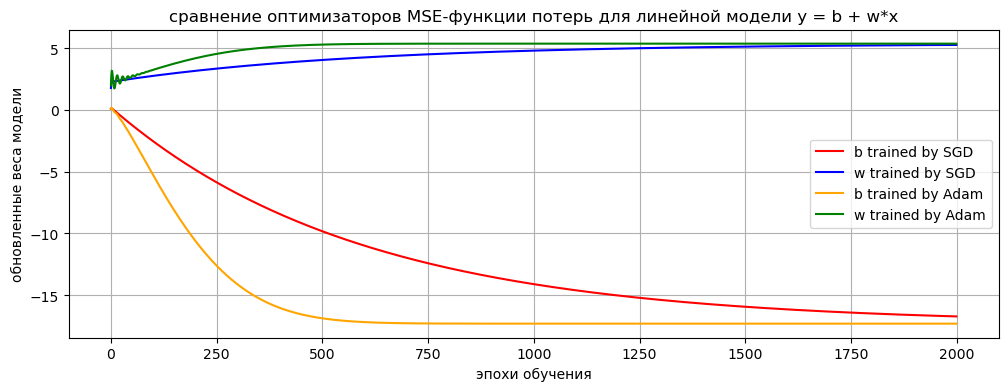

In [13]:
plt.figure(figsize=(12,4))

plt.plot(sgd_train_history[:2000,0], color='red', label='b trained by SGD')
plt.plot(sgd_train_history[:2000,1], color='blue', label='w trained by SGD')
plt.plot(adam_train_history[:,0], color='orange', label='b trained by Adam')
plt.plot(adam_train_history[:,1]*10, color='green', label='w trained by Adam')

plt.xlabel('эпохи обучения')
plt.ylabel('обновленные веса модели')
plt.title('сравнение оптимизаторов MSE-функции потерь для линейной модели y = b + w*x')
plt.grid()
plt.legend()
plt.show()

**Adam позволил в 10 раз увеличить скорость обучения, не теряя сходимости - так и видно на графике: 500 эпох для Adam и 5000 эпох для SGD**

# посмотрим на поведение функции потерь и выделим валидационную часть данных

## train-val split of data

In [14]:
n_samples = t_u.shape[0]
n_val = int(0.3 * n_samples)
n_val

3

In [15]:
shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 2,  1,  3,  9, 10,  8,  0,  7]), tensor([5, 4, 6]))

In [16]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

## модифицируем цикл обучения

In [17]:
def training_val_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    log = []
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, params)
        train_loss = loss_fn(train_t_p, train_t_c)
                             
        val_t_p = model(val_t_u, params)
        val_loss = loss_fn(val_t_p, val_t_c)
        
        optimizer.zero_grad()
        train_loss.backward()   # train_loss вычислялась только на train_data, и градиент будет посчитан только через train_X и train_y
        optimizer.step()

        if epoch <= 5 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                  f" Validation loss {val_loss.item():.4f}")
        if epoch == 5:
            print()
            print('params.requires_grad   =', params.requires_grad)
            print('val_t_p.requires_grad  =', val_t_p.requires_grad, '  val_t_p.grad   =', val_t_p.grad)
            print('val_loss.requires_grad =', val_loss.requires_grad, '  val_loss.grad  =', val_loss.grad)
            print('train_t_p.requires_grad  =', train_t_p.requires_grad)
            print('train_loss.requires_grad =', train_loss.requires_grad)
            print()
            
        log.append(list(params.detach().numpy().copy()) + [float(train_loss.detach()), float(val_loss.detach())])
            
    return params, np.array(log)

In [18]:
params = torch.tensor([0.0, 1.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

result, sgd_train_history = training_val_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_un, 
    val_t_u = val_t_un, 
    train_t_c = train_t_c,
    val_t_c = val_t_c)

result.detach()

Epoch 1, Training loss 105.6683, Validation loss 12.8870
Epoch 2, Training loss 43.1738, Validation loss 5.6773
Epoch 3, Training loss 35.8059, Validation loss 13.0579
Epoch 4, Training loss 34.8445, Validation loss 16.6699
Epoch 5, Training loss 34.6280, Validation loss 17.9845

params.requires_grad   = True
val_t_p.requires_grad  = True   val_t_p.grad   = None
val_loss.requires_grad = True   val_loss.grad  = None
train_t_p.requires_grad  = True
train_loss.requires_grad = True

Epoch 500, Training loss 7.8417, Validation loss 3.8118


/tmp/ipykernel_11780/679748714.py:20: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  print('val_t_p.requires_grad  =', val_t_p.requires_grad, '  val_t_p.grad   =', val_t_p.grad)
/tmp/ipykernel_11780/679748714.py:21: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, 

Epoch 1000, Training loss 3.5849, Validation loss 2.7439
Epoch 1500, Training loss 2.9228, Validation loss 3.0942
Epoch 2000, Training loss 2.8199, Validation loss 3.3523
Epoch 2500, Training loss 2.8039, Validation loss 3.4728
Epoch 3000, Training loss 2.8014, Validation loss 3.5232
Epoch 3500, Training loss 2.8010, Validation loss 3.5435
Epoch 4000, Training loss 2.8009, Validation loss 3.5516
Epoch 4500, Training loss 2.8009, Validation loss 3.5548
Epoch 5000, Training loss 2.8009, Validation loss 3.5560


tensor([-18.1339,   5.5392])

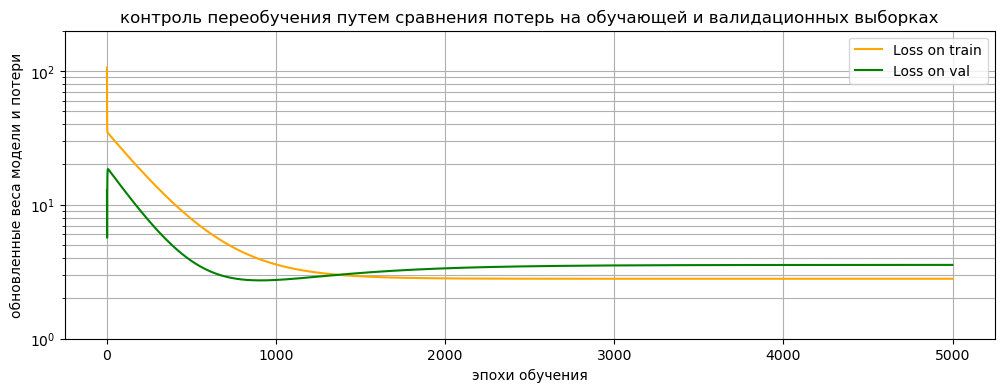

In [19]:
plt.figure(figsize=(12,4))

#plt.plot(sgd_train_history[:,0], color='red', label='b')
#plt.plot(sgd_train_history[:,1], color='blue', label='w')
plt.plot(sgd_train_history[:,2], color='orange', label='Loss on train')
plt.plot(sgd_train_history[:,3], color='green', label='Loss on val')

plt.yscale('log')
plt.ylim(1,200)
plt.xlabel('эпохи обучения')
plt.ylabel('обновленные веса модели и потери')
plt.title('контроль переобучения путем сравнения потерь на обучающей и валидационных выборках')
plt.grid(which='both')
plt.legend()
plt.show()

**заметим, что благодаря разделению тензоров и скаляров на train и val, образуются два независимых графа вычисления градиента методом `train_loss.backward()`, поэтому все честно: вклад в градиент от валидационных данных остается нулевым, и обучение не видит валидационных данных (до тех пор пока мы также не вызываем метод `val_loss.backward()`).  А вот если бы мы вызвал оба обратных хода, то просто получили бы полный градиент и обучение без выделения валидационных объектов**

## но построение графа для автограда идет и по валидационным значениям, увеличивая объем операций без всякого смысла.  Есть способ переписать код цикла обучения так, чтобы при использовании автограда не производились бы операции по валидационным объектам:

In [20]:
def training_val_no_grad_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    log = []
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, params)
        train_loss = loss_fn(train_t_p, train_t_c)
        if epoch == 5:
            print('params.requires_grad   =', params.requires_grad)
            print('val_t_p.requires_grad  =', val_t_p.requires_grad, '  val_t_p.grad   =', val_t_p.grad)
            print('val_loss.requires_grad =', val_loss.requires_grad, '  val_loss.grad  =', val_loss.grad)
            print('train_t_p.requires_grad  =', train_t_p.requires_grad)
            print('train_loss.requires_grad =', train_loss.requires_grad)
            print()

        with torch.no_grad():                      # выражение после with возвращает контекстный менеджер в методами enter() и exit()
            val_t_p = model(val_t_u, params)
            val_loss = loss_fn(val_t_p, val_t_c)
            if epoch == 5:
                print('From inside torch.no_grag() context:')
                print('params.requires_grad   =', params.requires_grad)
                print('val_t_p.requires_grad  =', val_t_p.requires_grad, '  val_t_p.grad   =', val_t_p.grad)
                print('val_loss.requires_grad =', val_loss.requires_grad, '  val_loss.grad  =', val_loss.grad)
                print('train_t_p.requires_grad  =', train_t_p.requires_grad)
                print('train_loss.requires_grad =', train_loss.requires_grad)
                print()
                
            assert val_loss.requires_grad == False # <2>
            
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        log.append(list(params.detach().numpy().copy()) + [float(train_loss.detach()), float(val_loss.detach())])
        
    return params, np.array(log)

In [21]:
params = torch.tensor([0.0, 1.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

result, sgd_train_history = training_val_no_grad_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_un, 
    val_t_u = val_t_un, 
    train_t_c = train_t_c,
    val_t_c = val_t_c)

result.detach()

params.requires_grad   = True
val_t_p.requires_grad  = False   val_t_p.grad   = None
val_loss.requires_grad = False   val_loss.grad  = None
train_t_p.requires_grad  = True
train_loss.requires_grad = True

From inside torch.no_grag() context:
params.requires_grad   = True
val_t_p.requires_grad  = False   val_t_p.grad   = None
val_loss.requires_grad = False   val_loss.grad  = None
train_t_p.requires_grad  = True
train_loss.requires_grad = True



tensor([-18.1339,   5.5392])

## чтобы не разматывать портянку с одним кодом в двух контекстах, можно обернуть вычисление функции потерь в функцию с параметром, задающим градиентный контекст вычисления функции потерь:

In [22]:
def cv_calculate_loss_forward(t_u, t_c, is_train):
    with torch.set_grad_enabled(is_train):
        t_p = model(t_u, params)
        loss = loss_fn(t_p, t_c)
    return loss

In [23]:
def training_cv_grad_context_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    log = []
    for epoch in range(1, n_epochs + 1):
        train_loss = cv_calculate_loss_forward(t_u=train_t_u, t_c=train_t_c, is_train=True)
        val_loss = cv_calculate_loss_forward(t_u=val_t_u, t_c=val_t_c, is_train=False)
            
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        log.append(list(params.detach().numpy().copy()) + [float(train_loss.detach()), float(val_loss.detach())])
        
    return params, np.array(log)

In [24]:
params = torch.tensor([0.0, 1.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

result, sgd_train_history = training_cv_grad_context_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_un, 
    val_t_u = val_t_un, 
    train_t_c = train_t_c,
    val_t_c = val_t_c
)

result.detach()

tensor([-18.1339,   5.5392])